# Village focus 

For this study, we will focus on the village listed in : [List_villages.xlsx](C:\Users\charl\solar-data-china\scripts\satellite_image\List_villages.xlsx)



## Setup 

In [76]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import mapping, shape, Polygon
import plotly.express as px
import seaborn as sns
import os
import rasterio
from collections import defaultdict
from difflib import SequenceMatcher
from pypinyin import lazy_pinyin
import folium

## County Selection Overview

In [2]:
village_list = pd.read_excel("List_villages.xlsx")

In [3]:
village_list.head()

,Province,Province_pinyin,Province code,City,City_pinyin,City code,County,County_pinyin,County code,Township,Township_pinyin,Village,Village_pinyin
0,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,北峰乡,bei feng xiang,东夹河村委会,dong jia he cun wei hui
1,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,埝头乡,nian tou xiang,朱村村村委会,zhu cun cun cun wei hui
2,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,大名镇,da ming zhen,吴水坑村委会,wu shui keng cun wei hui
3,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,大街乡,da jie xiang,张郭村委会,zhang guo cun wei hui
4,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,张铁集乡,zhang tie ji xiang,北刘店村委会,bei liu dian cun wei hui


In [4]:
count_province = village_list['Province_pinyin'].nunique()
count_county = village_list['County_pinyin'].nunique()
count_town = village_list['Township_pinyin'].nunique()
count_village = village_list['Village_pinyin'].nunique()

print(f"Number of provinces: {count_province}")
print(f"Number of counties: {count_county}")
print(f"Number of towns: {count_town}")
print(f"Number of villages: {count_village}")


Number of provinces: 8
Number of counties: 15
Number of towns: 91
Number of villages: 111


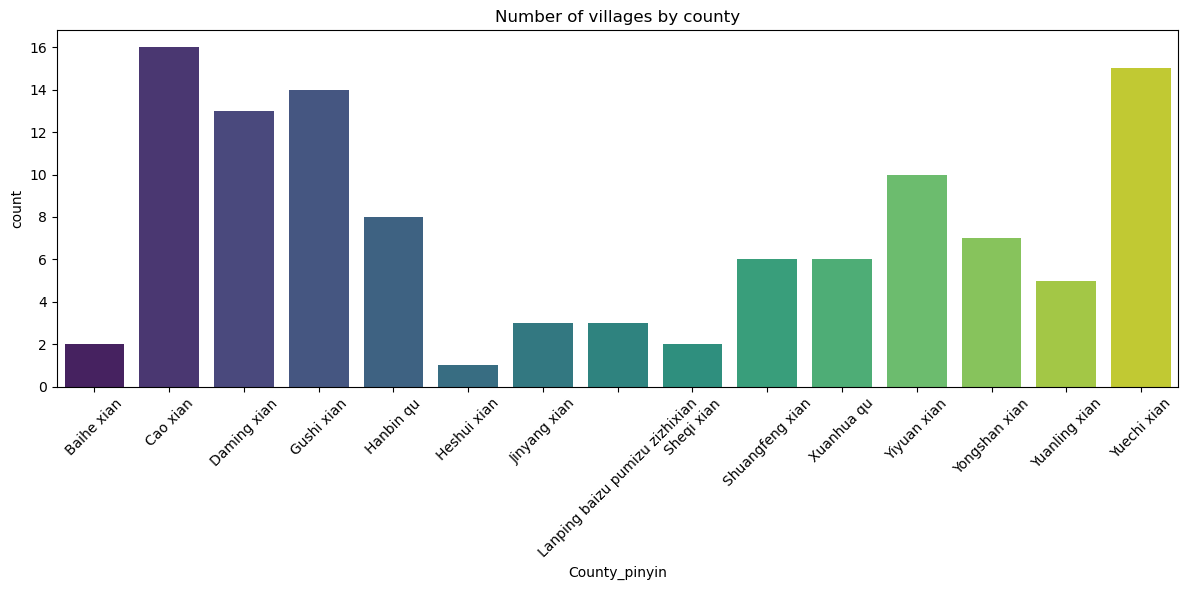

In [5]:
count_by_counties = village_list.groupby('County_pinyin').size().reset_index(name='count')

plt.figure(figsize=(12, 6))

# Create barplot with viridis palette
sns.barplot(
    data=count_by_counties, 
    x='County_pinyin',
    y='count',
    hue='County_pinyin',
    palette=sns.color_palette("viridis", n_colors=len(count_by_counties))
)

# Set title and show plot
plt.title('Number of villages by county')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Get the Township Geometry

In [6]:
townships_geom = gpd.read_file(r"C:\Users\charl\solar-data-china\data\data_processed\mapdata\chinatownships.geojson")

In [7]:
townships_geom.head()

,geom,省,Province_pinyin,市,City_pinyin,县,County_pinyin,乡,Township_pinyin,geometry
0,SRID=4326;MULTIPOLYGON(((113.58654372861 32.43...,河南省,he nan sheng,南阳市,nan yang shi,桐柏县,tong bai xian,吴城镇,wu cheng zhen,"POLYGON ((113.58 32.433, 113.59 32.427, 113.59..."
1,SRID=4326;MULTIPOLYGON(((114.655030581138 33.6...,河南省,he nan sheng,周口市,zhou kou shi,川汇区,chuan hui qu,陈州回族街道,chen zhou hui zu jie dao,"POLYGON ((114.65 33.624, 114.65 33.62, 114.65 ..."
2,SRID=4326;MULTIPOLYGON(((115.026098835668 34.2...,河南省,he nan sheng,商丘市,shang qiu shi,睢县,sui xian,孙聚寨乡,sun ju zhai xiang,"POLYGON ((115.02 34.289, 115.02 34.287, 115.02..."
3,SRID=4326;MULTIPOLYGON(((112.227729849696 32.6...,河南省,he nan sheng,南阳市,nan yang shi,邓州市,deng zhou shi,白牛镇,bai niu zhen,"POLYGON ((112.22 32.685, 112.22 32.685, 112.21..."
4,SRID=4326;MULTIPOLYGON(((114.646057216599 33.6...,河南省,he nan sheng,周口市,zhou kou shi,川汇区,chuan hui qu,荷花街道,he hua jie dao,"POLYGON ((114.64 33.613, 114.64 33.605, 114.64..."


In [8]:
def check_townships(village_list, townships_geom):
    """
    Checks which villages/townships from the list are found in the GeoDataFrame of townships.

    Args:
        village_list (DataFrame): columns ['Province','City','County','Township','Village']
        townships_geom (GeoDataFrame): columns ['省','市','县','乡','geometry']

    Returns:
        found (list): list of dicts with matched geometry
        not_found (list): list of tuples (dict, fail_levels)
    """
    found = []
    not_found = []

    for _, entry in village_list.iterrows():
        # Partial match for Province (Chinese characters)
        province_match = townships_geom['省'].str.contains(entry['Province'], na=False)
        matches = townships_geom[
            province_match &
            (townships_geom['市'] == entry['City']) &
            (townships_geom['县'] == entry['County']) &
            (townships_geom['乡'] == entry['Township'])
        ]

        if not matches.empty:
            # Save the geometry for the matched township
            entry_with_geom = entry.to_dict()
            entry_with_geom['geometry'] = matches.iloc[0].geometry
            found.append(entry_with_geom)
        else:
        # Check which administrative level(s) failed
            fail_levels = []

            # Check Province
            if not province_match.any():
                fail_levels.append("Province")
            else:
                # Check City within matched Province
                city_match = townships_geom.loc[province_match, '市'] == entry['City']
                if not city_match.any():
                    fail_levels.append("City")
                else:
                    # Check County within matched Province & City
                    county_match = townships_geom.loc[province_match & city_match, '县'] == entry['County']
                    if not county_match.any():
                        fail_levels.append("County")
                    else:
                        # Check Township within matched Province, City & County
                        township_match = townships_geom.loc[province_match & city_match & county_match, '乡'] == entry['Township']
                        if not township_match.any():
                            fail_levels.append("Township")

            not_found.append((entry.to_dict(), fail_levels))

    # Print summary
    print("Townships found:")
    for e in found:
        print(f"{e['Province']} - {e['City']} - {e['County']} - {e['Township']}")

    print("\nTownships NOT found:")
    for e, levels in not_found:
        print(f"{e['Province']} - {e['City']} - {e['County']} - {e['Township']}")
        if levels:
            print(f"  -> Failed at level(s): {', '.join(levels)}")
        else:
            print("  -> Not found, unknown level")

    return found, not_found


In [9]:
found, not_found = check_townships(village_list, townships_geom)

Townships found:
河北 - 邯郸市 - 大名县 - 北峰乡
河北 - 邯郸市 - 大名县 - 埝头乡
河北 - 邯郸市 - 大名县 - 大名镇
河北 - 邯郸市 - 大名县 - 大街乡
河北 - 邯郸市 - 大名县 - 张铁集乡
河北 - 邯郸市 - 大名县 - 张铁集乡
河北 - 邯郸市 - 大名县 - 张铁集乡
河北 - 邯郸市 - 大名县 - 杨桥镇
河北 - 邯郸市 - 大名县 - 西付集乡
河北 - 邯郸市 - 大名县 - 西未庄乡
河北 - 邯郸市 - 大名县 - 金滩镇
河北 - 邯郸市 - 大名县 - 铺上乡
河北 - 邯郸市 - 大名县 - 龙王庙镇
山东 - 淄博市 - 沂源县 - 中庄镇
山东 - 淄博市 - 沂源县 - 南鲁山镇
山东 - 淄博市 - 沂源县 - 大张庄镇
山东 - 淄博市 - 沂源县 - 悦庄镇
山东 - 淄博市 - 沂源县 - 悦庄镇
山东 - 淄博市 - 沂源县 - 悦庄镇
山东 - 淄博市 - 沂源县 - 燕崖镇
山东 - 淄博市 - 沂源县 - 燕崖镇
山东 - 淄博市 - 沂源县 - 鲁村镇
山东 - 淄博市 - 沂源县 - 鲁村镇
山东 - 菏泽市 - 曹县 - 普连集镇
山东 - 菏泽市 - 曹县 - 桃源集镇
山东 - 菏泽市 - 曹县 - 梁堤头镇
山东 - 菏泽市 - 曹县 - 苏集镇
山东 - 菏泽市 - 曹县 - 青岗集镇
山东 - 菏泽市 - 曹县 - 青菏街道
河南 - 南阳市 - 社旗县 - 大冯营镇
河南 - 南阳市 - 社旗县 - 桥头镇
河南 - 信阳市 - 固始县 - 分水亭镇
河南 - 信阳市 - 固始县 - 张广庙镇
河南 - 信阳市 - 固始县 - 徐集乡
河南 - 信阳市 - 固始县 - 武庙集镇
河南 - 信阳市 - 固始县 - 泉河铺镇
河南 - 信阳市 - 固始县 - 祖师庙镇
河南 - 信阳市 - 固始县 - 胡族铺镇
河南 - 信阳市 - 固始县 - 草庙集乡
河南 - 信阳市 - 固始县 - 观堂乡
河南 - 信阳市 - 固始县 - 赵岗乡
河南 - 信阳市 - 固始县 - 陈淋子镇
河南 - 信阳市 - 固始县 - 陈集镇
湖南 - 怀化市 - 沅陵县 - 五强溪镇
湖南 - 怀化市 - 沅陵县 - 明溪口镇
湖南 - 怀化市 - 沅陵县 - 明溪口

In [10]:
print("Number of township founded :" , len(found))
print("Number of township not founded :" , len(not_found))

Number of township founded : 93
Number of township not founded : 18


In [11]:
# For each unfound township, let's examine the townships available in that county 
# to understand why it was not matched — for example, due to errors, different naming conventions, etc.

# Dictionary to group entries by (Province, City, County)
county_groups = defaultdict(list)
for entry_dict, fail_levels in not_found:
    entry = pd.Series(entry_dict)
    key = (entry['Province'], entry['City'], entry['County'])
    county_groups[key].append(entry['Township'])


# Analyze each county separately
for (province, city, county), missing_townships in county_groups.items():
    print(f"\nAnalyzing '{province}' - '{city}' - '{county}'")

    missing_series = pd.Series(missing_townships)
    print("Unfound townships we are trying to locate:", missing_series.unique())

    county_mask = (
        (townships_geom['省'].str.contains(province)) &
        (townships_geom['市'] == city) &
        (townships_geom['县'] == county)
    )
    county_df = townships_geom[county_mask]
    
    if county_df.empty:
        print(f"County '{county}' not found in dataset. Skipping detailed township check.")
        continue
    
    # Print all townships available in this county
    available_townships = county_df['乡'].unique()
    print("\nAvailable townships in this county:", available_townships)
    print('---------------------------------------------------------------------')




Analyzing '河北' - '张家口市' - '宣化区'
Unfound townships we are trying to locate: ['崞村镇' '江家屯乡' '深井镇' '王家湾乡' '贾家营镇']

Available townships in this county: ['大北街街道' '天泰寺街道' '南关街道' '皇城街道' '南大街街道' '春光乡' '河子西乡' '侯家庙乡' '工业街街道' '建国街街道'
 '庞家堡镇']
---------------------------------------------------------------------

Analyzing '山东' - '菏泽市' - '曹县'
Unfound townships we are trying to locate: ['倪集街道' '安蔡楼镇' '楼庄乡' '王集镇' '郑庄街道' '青堌集镇']

Available townships in this county: ['曹县王集镇' '曹县邵庄镇' '曹县常乐集乡' '曹县朱洪庙乡' '侯集回族镇' '曹县仵楼乡' '庄寨镇' '曹城街道' '曹县倪集镇'
 '曹县大集乡' '曹县楼庄乡' '砖庙镇' '苏集镇' '郑庄镇' '韩集镇' '魏湾镇' '古营集镇' '孙老家镇' '安才楼镇' '普连集镇'
 '桃源集镇' '梁堤头镇' '磐石街道' '阎店楼镇' '青固集镇' '青岗集镇' '青菏街道']
---------------------------------------------------------------------

Analyzing '河南' - '信阳市' - '固始县'
Unfound townships we are trying to locate: ['李店镇' '马堽集镇']

Available townships in this county: ['蒋集镇' '分水亭镇' '南大桥乡' '番城街道' '张老埠乡' '柳树店乡' '秀水街道' '丰港乡' '沙河铺乡' '往流镇' '泉河铺镇'
 '徐集乡' '杨集乡' '方集镇' '李店乡' '段集镇' '汪棚镇' '洪埠乡' '石佛店镇' '观堂乡' '黎集镇' '三河尖镇'
 '张广庙镇

We notice that in some cases the “unfound” townships are very similar to existing ones in the dataset.
For example: 青堌集镇 vs 青固集镇 (only one (very similar) character different) or 李店镇 vs 李店乡 (different administrative suffix but likely referring to the same area) or 王集镇 vs 曹县王集镇 (the same township name but with the county name prefixed).

This suggests that some “unfound” townships are in fact present in the dataset, but with slightly different spellings, characters or naming conventions.
As a first step, for each township that is not found, we should try to identify the most similar township(s) within the same county or city and associate them. This will help us detect probable matches before deciding whether they are true errors or just naming variations.

In [79]:
# convert to pinyin string
def to_pinyin(s):
    return ' '.join(pypinyin.lazy_pinyin(s))

for (province, city, county), missing_townships in county_groups.items():
    print(f"\n Analyzing county: {province}-{city}-{county}")

    # restrict available townships to this county
    county_mask = (
        (townships_geom['省'].str.contains(province)) &
        (townships_geom['市'] == city) &
        (townships_geom['县'] == county)
    )
    county_df = townships_geom[county_mask]

    available_townships = county_df['乡'].unique()

    missing_series = pd.Series(missing_townships)

    for unf in missing_series.unique():
        unf_pinyin = to_pinyin(unf)

        print(f"\n Checking unfound township: {unf} ({unf_pinyin})")
        candidates = []

        for avail in available_townships:
            avail_pinyin = to_pinyin(avail)

            # similarity in characters
            char_sim = SequenceMatcher(None, unf, avail).ratio()
            # similarity in pinyin
            py_sim = SequenceMatcher(None, unf_pinyin, avail_pinyin).ratio()

            # flag if close match
            if char_sim > 0.5 or py_sim > 0.75:
                candidates.append((avail, char_sim, py_sim, avail_pinyin))

        if candidates:
            print("   Possible matches:")
            for cand, cs, ps, py in sorted(candidates, key=lambda x: max(x[1], x[2]), reverse=True)[:5]:
                print(f"     - {cand} ({py}) | char_sim={cs:.2f}, pinyin_sim={ps:.2f}")
        else:
            print("   No close matches found.")
    
    print('---------------------------------------------------------------------')



 Analyzing county: 河北-张家口市-宣化区

 Checking unfound township: 崞村镇 (guo cun zhen)
   No close matches found.

 Checking unfound township: 江家屯乡 (jiang jia tun xiang)
   No close matches found.

 Checking unfound township: 深井镇 (shen jing zhen)
   No close matches found.

 Checking unfound township: 王家湾乡 (wang jia wan xiang)
   No close matches found.

 Checking unfound township: 贾家营镇 (jia jia ying zhen)
   No close matches found.
---------------------------------------------------------------------

 Analyzing county: 山东-菏泽市-曹县

 Checking unfound township: 倪集街道 (ni ji jie dao)
   Possible matches:
     - 磐石街道 (pan shi jie dao) | char_sim=0.50, pinyin_sim=0.79

 Checking unfound township: 安蔡楼镇 (an cai lou zhen)
   Possible matches:
     - 安才楼镇 (an cai lou zhen) | char_sim=0.75, pinyin_sim=1.00
     - 阎店楼镇 (yan dian lou zhen) | char_sim=0.50, pinyin_sim=0.81

 Checking unfound township: 楼庄乡 (lou zhuang xiang)
   Possible matches:
     - 曹县楼庄乡 (cao xian lou zhuang xiang) | char_sim=0.75, piny

For several unfound townships, we identified potential matches in the dataset based on character similarity and pinyin similarity. The following table summarizes which townships we should verify manually to confirm if they are indeed the same:

- 河北-张家口市-宣化区
    - **No close matches found for all the townships**


- 山东-菏泽市-曹县

    - 倪集街道 → 曹县倪集镇
    - 安蔡楼镇 → Possible match: 安才楼镇
    - 楼庄乡 → Possible match: 曹县楼庄乡 
    - 王集镇 → Possible match : 曹县王集镇
    - 郑庄街道 → Possible match: 郑庄镇 
    - 青堌集镇 → Possible matches: 青固集镇, 青岗集镇

- 河南-信阳市-固始县
    - 李店镇 → Possible match: 李店乡 
    - 马堽集镇 → Possible match : 马堽集乡

In [19]:
def plot_township_match(province, city, county, unfound_name, lat, lon, candidate_names):
    """
    Plot potential townships boundaries, unfound township point and see if they really match. 

    """
    
    # Filter the county
    county_mask = (
        (townships_geom['省'].str.contains(province)) &
        (townships_geom['市'] == city) &
        (townships_geom['县'] == county)
    )
    county_townships = townships_geom[county_mask]
    print(f"\n Analyzing county: {province}-{city}-{county}")

    # Center map on county
    # Reproject to projected CRS before centroid 
    county_townships_proj = county_townships.to_crs(epsg=3857)
    center = county_townships_proj.geometry.centroid.to_crs(epsg=4326).iloc[0]
    
    m = folium.Map(location=[center.y, center.x], zoom_start=11)

    # Add all township boundaries (in grey)
    folium.GeoJson(
        county_townships.to_json(),
        name="Townships",
        style_function=lambda x: {"color": "black", "weight": 1, "fillOpacity": 0.1},
        tooltip=folium.GeoJsonTooltip(fields=['乡'], aliases=['Township:'])
    ).add_to(m)

    # Add candidate matches in red
    candidates = county_townships[county_townships['乡'].isin(candidate_names)]
    if not candidates.empty:
        folium.GeoJson(
            candidates.to_json(),
            name="Candidates",
            style_function=lambda x: {"color": "red", "weight": 2, "fillOpacity": 0.2},
            tooltip=folium.GeoJsonTooltip(fields=['乡'], aliases=['Candidate:'])
        ).add_to(m)

    # Add point for unfound township
    folium.Marker(
        [lat, lon],
        popup=f"{unfound_name}",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)

    return m


In [20]:
match = [
    {
        "province": "河北",
        "city": "张家口市",
        "county": "宣化区",
        "unfound_name": "崞村镇",
        "lat": 40.48750841687082, # coordinate of the unfound townships from google maps 
        "lon": 115.01657410999863,
        "candidate_names": []
    },
    {
        "province": "河北",
        "city": "张家口市",
        "county": "宣化区",
        "unfound_name": "江家屯乡",
        "lat": 40.60761421172825, 
        "lon": 114.95436502543575,
        "candidate_names": []
    },
    {
        "province": "河北",
        "city": "张家口市",
        "county": "宣化区",
        "unfound_name": "深井镇",
        "lat": 40.40431009545453, 
        "lon": 114.83789864092165,
        "candidate_names": []
    },
    {
        "province": "河北",
        "city": "张家口市",
        "county": "宣化区",
        "unfound_name": "王家湾乡",
        "lat":40.26580749741699,
        "lon":  114.8527544536483,
        "candidate_names": []
    },
    {
        "province": "河北",
        "city": "张家口市",
        "county": "宣化区",
        "unfound_name": "贾家营镇",
        "lat": 40.616325062288965, 
        "lon": 115.21905323173779,
        "candidate_names": []
    },


    {
        "province": "山东",
        "city": "菏泽市",
        "county": "曹县",
        "unfound_name": "倪集街道",
        "lat": 34.868513641317215, 
        "lon": 115.49462602598743,
        "candidate_names": ["曹县倪集镇"]
    },
    {
        "province": "山东",
        "city": "菏泽市",
        "county": "曹县",
        "unfound_name": "安蔡楼镇",
        "lat": 34.70157998864923, 
        "lon": 115.68212655010417,
        "candidate_names": ["安才楼镇"]
    },
    {
        "province": "山东",
        "city": "菏泽市",
        "county": "曹县",
        "unfound_name": "楼庄乡",
        "lat": 34.85831030418538, 
        "lon": 115.26187119049405,
        "candidate_names": ["曹县楼庄乡"]
    },
    {
        "province": "山东",
        "city": "菏泽市",
        "county": "曹县",
        "unfound_name": "王集镇",
        "lat": 34.8354111406043, 
        "lon": 115.63797270270915, 
        "candidate_names": ["曹县王集镇"]
    },
    {
        "province": "山东",
        "city": "菏泽市",
        "county": "曹县",
        "unfound_name": "郑庄街道",
        "lat":34.78553497485151, 
        "lon": 115.51493404221513,
        "candidate_names": ["郑庄镇"]
    },
    {
        "province": "山东",
        "city": "菏泽市",
        "county": "曹县",
        "unfound_name": "青堌集镇",
        "lat": 34.69547104986513, 
        "lon": 115.79543961886502,
        "candidate_names": ["青固集镇","青岗集镇"]
    },


    {
        "province": "河南",
        "city": "信阳市",
        "county": "固始县",
        "unfound_name": "李店镇",
        "lat": 32.34652563792079, 
        "lon": 115.68300048828739,
        "candidate_names": ["李店乡"]
    },
    {
        "province": "河南",
        "city": "信阳市",
        "county": "固始县",
        "unfound_name": "马堽集镇",
        "lat": 32.089449951986296, 
        "lon": 115.42894029807928,
        "candidate_names": ["马堽集乡"]
    }

]

df = pd.DataFrame(match)
df

,province,city,county,unfound_name,lat,lon,candidate_names
0,河北,张家口市,宣化区,崞村镇,40.487508,115.016574,[]
1,河北,张家口市,宣化区,江家屯乡,40.607614,114.954365,[]
2,河北,张家口市,宣化区,深井镇,40.404310,114.837899,[]
3,河北,张家口市,宣化区,王家湾乡,40.265807,114.852754,[]
4,河北,张家口市,宣化区,贾家营镇,40.616325,115.219053,[]
5,山东,菏泽市,曹县,倪集街道,34.868514,115.494626,[曹县倪集镇]
6,山东,菏泽市,曹县,安蔡楼镇,34.701580,115.682127,[安才楼镇]
7,山东,菏泽市,曹县,楼庄乡,34.858310,115.261871,[曹县楼庄乡]
8,山东,菏泽市,曹县,王集镇,34.835411,115.637973,[曹县王集镇]
9,山东,菏泽市,曹县,郑庄街道,34.785535,115.514934,[郑庄镇]


In [21]:
for idx, row in df.iterrows():
    m = plot_township_match(
        row['province'], row['city'], row['county'], 
        row['unfound_name'], row['lat'], row['lon'], 
        row['candidate_names']
    )
    display(m)


 Analyzing county: 河北-张家口市-宣化区



 Analyzing county: 河北-张家口市-宣化区



 Analyzing county: 河北-张家口市-宣化区



 Analyzing county: 河北-张家口市-宣化区



 Analyzing county: 河北-张家口市-宣化区


...


 Analyzing county: 山东-菏泽市-曹县



 Analyzing county: 山东-菏泽市-曹县



 Analyzing county: 山东-菏泽市-曹县



 Analyzing county: 河南-信阳市-固始县



 Analyzing county: 河南-信阳市-固始县


Our hypothesis holds for most counties, but in Xuanhua District the mismatches suggest inconsistencies or missing data, so further investigation is needed.

In [16]:
gadam = gpd.read_file(r"C:\Users\charl\solar-data-china\data\data_processed\mapdata\gadm41_CHN_3_processed.json")

In [23]:
# Filter townships of 宣化区 (Xuanhua Qu) in 张家口市, 河北省
county_mask = (
    (townships_geom['省'].str.contains('河北')) &
    (townships_geom['市'] == '张家口市') &
    (townships_geom['县'] == '宣化区')
)
xuanhua_townships = townships_geom[county_mask]

# Get centroid of county for initial map location
county_townships_proj = xuanhua_townships.to_crs(epsg=3857)
center = county_townships_proj.geometry.centroid.to_crs(epsg=4326).iloc[0]
m = folium.Map(location=[center.y, center.x], zoom_start=11)


county_gadam = gadam[gadam["County"] == "Xuanhua"]

# Add township boundaries
folium.GeoJson(
    xuanhua_townships.to_json(),
    name="Townships",
    color= 'red',
    tooltip=folium.GeoJsonTooltip(fields=['乡'], aliases=['Township:'])
).add_to(m)

folium.GeoJson(county_gadam).add_to(m)
m


For Xuanhua County the overlay with GADM does not align—instead of overlapping, the datasets appear almost complementary ! 

In [31]:
# Filter townships of 张家口市 (Zhangjiakou)
prefecture_mask = (
    (townships_geom['省'].str.contains('河北')) &
    (townships_geom['市'] == '张家口市') 
)
zhangjiakou_townships = townships_geom[prefecture_mask]
zhangjiakou_counties = zhangjiakou_townships.dissolve(by="县").reset_index()

# Get centroid of 张家口市 for map center
prefecture_proj = zhangjiakou_counties.to_crs(epsg=3857)
center = prefecture_proj.geometry.centroid.to_crs(epsg=4326).iloc[0]
m = folium.Map(location=[center.y, center.x], zoom_start=9)

# Filter Xuanhua county from gadam
county_gadam = gadam[gadam["County"] == "Xuanhua"]

# Overlay GADAM boundary
folium.GeoJson(
    county_gadam.to_json(),
    name="GADAM Xuanhua",
    style_function=lambda x: {"color": "blue", "weight": 2, "fillOpacity": 0.05}
).add_to(m)


# Add county boundaries (instead of townships)
folium.GeoJson(
    zhangjiakou_counties.to_json(),
    name="Counties",
    style_function=lambda x: {"color": "red", "weight": 2, "fillOpacity": 0.05},
    tooltip=folium.GeoJsonTooltip(fields=['县'], aliases=['County:'])
).add_to(m)


m


We observed that Xuanhua Qu actually corresponds to the combination of Xuanhua Qu and Xuanhua Xian.

In [44]:
xuanhua_unfound = df[df['county'] == '宣化区']['unfound_name']
print("Unfound townships :" ,list(xuanhua_unfound))


xuanhua_groups = townships_geom[
        (townships_geom['省'].str.contains("河北")) &
        (townships_geom['市'] == "张家口市") &
        (townships_geom['县'].str.contains("宣化"))
]

print(xuanhua_groups[['县', '乡']])

# Check if each unfound township exists in xuanhua_groups
found_status = {}
for name in xuanhua_unfound:
    if name in xuanhua_groups['乡'].values:
        found_status[name] = True
    else:
        found_status[name] = False

for town, status in found_status.items():
    print(f"{town}: {'Found' if status else 'Not Found'} in xuanhua_groups")

Unfound townships : ['崞村镇', '江家屯乡', '深井镇', '王家湾乡', '贾家营镇']
         县      乡
4013   宣化区  大北街街道
4046   宣化区  天泰寺街道
7221   宣化区   南关街道
7223   宣化区   皇城街道
7225   宣化区  南大街街道
7923   宣化区    春光乡
7925   宣化区   河子西乡
7926   宣化区   侯家庙乡
7927   宣化区  工业街街道
7928   宣化区  建国街街道
7929   宣化县   姚家房镇
7930   宣化县    赵川镇
7931   宣化县   东望山乡
7932   宣化县   塔儿村乡
7933   宣化县   大仓盖镇
7934   宣化县   李家堡乡
7936   宣化县   江家屯乡
7940   宣化县   沙岭子镇
7942   宣化县   洋河南镇
7945   宣化县   贾家营镇
7946   宣化县   顾家营镇
27481  宣化区   庞家堡镇
27482  宣化县    崞村镇
27483  宣化县    深井镇
27485  宣化县   王家湾乡
崞村镇: Found in xuanhua_groups
江家屯乡: Found in xuanhua_groups
深井镇: Found in xuanhua_groups
王家湾乡: Found in xuanhua_groups
贾家营镇: Found in xuanhua_groups


We have found all the townships. Let's replace the names and correct our dataset to get the all geometry. 

In [47]:
# Create a dictionary mapping unfound_name -> first candidate_name
candidate_map = {
    row['unfound_name']: (row['candidate_names'][0] if row['candidate_names'] else None)
    for _, row in df.iterrows()
}

candidate_map

{'崞村镇': None,
 '江家屯乡': None,
 '深井镇': None,
 '王家湾乡': None,
 '贾家营镇': None,
 '倪集街道': '曹县倪集镇',
 '安蔡楼镇': '安才楼镇',
 '楼庄乡': '曹县楼庄乡',
 '王集镇': '曹县王集镇',
 '郑庄街道': '郑庄镇',
 '青堌集镇': '青固集镇',
 '李店镇': '李店乡',
 '马堽集镇': '马堽集乡'}

In [80]:
def update_village(row):
    # Update Xuanhua county
    if row['County'] == "宣化区":
        row['County'] = "宣化县" 
        row['County_pinyin'] = "Xuanhua xian"
    # Update township if it matches an unfound_name with candidate
    if row['Township'] in candidate_map and candidate_map[row['Township']]:
        row['Township'] = candidate_map[row['Township']]
        row['Township_pinyin'] = to_pinyin(row['Township'])
    return row

village_list_updated = village_list.apply(update_village, axis=1)

print(village_list_updated)


    Province Province_pinyin  Province code City City_pinyin  City code  \
0         河北           Hebei             13  邯郸市      Handan       1304   
1         河北           Hebei             13  邯郸市      Handan       1304   
2         河北           Hebei             13  邯郸市      Handan       1304   
3         河北           Hebei             13  邯郸市      Handan       1304   
4         河北           Hebei             13  邯郸市      Handan       1304   
..       ...             ...            ...  ...         ...        ...   
106       陕西         Shaanxi             61  安康市      Ankang       6109   
107       陕西         Shaanxi             61  安康市      Ankang       6109   
108       陕西         Shaanxi             61  安康市      Ankang       6109   
109       陕西         Shaanxi             61  安康市      Ankang       6109   
110       甘肃           Gansu             62  庆阳市    Qingyang       6210   

    County County_pinyin  County code Township     Township_pinyin  Village  \
0      大名县   Daming 

In [81]:
found, not_found = check_townships(village_list_updated, townships_geom)

Townships found:
河北 - 邯郸市 - 大名县 - 北峰乡
河北 - 邯郸市 - 大名县 - 埝头乡
河北 - 邯郸市 - 大名县 - 大名镇
河北 - 邯郸市 - 大名县 - 大街乡
河北 - 邯郸市 - 大名县 - 张铁集乡
河北 - 邯郸市 - 大名县 - 张铁集乡
河北 - 邯郸市 - 大名县 - 张铁集乡
河北 - 邯郸市 - 大名县 - 杨桥镇
河北 - 邯郸市 - 大名县 - 西付集乡
河北 - 邯郸市 - 大名县 - 西未庄乡
河北 - 邯郸市 - 大名县 - 金滩镇
河北 - 邯郸市 - 大名县 - 铺上乡
河北 - 邯郸市 - 大名县 - 龙王庙镇
河北 - 张家口市 - 宣化县 - 崞村镇
河北 - 张家口市 - 宣化县 - 江家屯乡
河北 - 张家口市 - 宣化县 - 深井镇
河北 - 张家口市 - 宣化县 - 王家湾乡
河北 - 张家口市 - 宣化县 - 贾家营镇
河北 - 张家口市 - 宣化县 - 贾家营镇
山东 - 淄博市 - 沂源县 - 中庄镇
山东 - 淄博市 - 沂源县 - 南鲁山镇
山东 - 淄博市 - 沂源县 - 大张庄镇
山东 - 淄博市 - 沂源县 - 悦庄镇
山东 - 淄博市 - 沂源县 - 悦庄镇
山东 - 淄博市 - 沂源县 - 悦庄镇
山东 - 淄博市 - 沂源县 - 燕崖镇
山东 - 淄博市 - 沂源县 - 燕崖镇
山东 - 淄博市 - 沂源县 - 鲁村镇
山东 - 淄博市 - 沂源县 - 鲁村镇
山东 - 菏泽市 - 曹县 - 曹县倪集镇
山东 - 菏泽市 - 曹县 - 曹县倪集镇
山东 - 菏泽市 - 曹县 - 曹县倪集镇
山东 - 菏泽市 - 曹县 - 安才楼镇
山东 - 菏泽市 - 曹县 - 安才楼镇
山东 - 菏泽市 - 曹县 - 普连集镇
山东 - 菏泽市 - 曹县 - 桃源集镇
山东 - 菏泽市 - 曹县 - 梁堤头镇
山东 - 菏泽市 - 曹县 - 曹县楼庄乡
山东 - 菏泽市 - 曹县 - 曹县王集镇
山东 - 菏泽市 - 曹县 - 苏集镇
山东 - 菏泽市 - 曹县 - 郑庄镇
山东 - 菏泽市 - 曹县 - 青固集镇
山东 - 菏泽市 - 曹县 - 青固集镇
山东 - 菏泽市 - 曹县 - 青岗集镇
山东 - 菏泽市 - 曹县 - 青菏街道
河南 - 南阳市 - 社旗县 - 

In [82]:
village_list_df = pd.DataFrame(found)
village_list_df.head()

,Province,Province_pinyin,Province code,City,City_pinyin,City code,County,County_pinyin,County code,Township,Township_pinyin,Village,Village_pinyin,geometry
0,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,北峰乡,bei feng xiang,东夹河村委会,dong jia he cun wei hui,"POLYGON ((115.4311583592735 36.2076001176948, ..."
1,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,埝头乡,nian tou xiang,朱村村村委会,zhu cun cun cun wei hui,"POLYGON ((115.4096093750005 36.13738715277807,..."
2,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,大名镇,da ming zhen,吴水坑村委会,wu shui keng cun wei hui,"POLYGON ((115.1486734531898 36.26495861098542,..."
3,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,大街乡,da jie xiang,张郭村委会,zhang guo cun wei hui,"POLYGON ((115.1889325056097 36.3106562523592, ..."
4,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,张铁集乡,zhang tie ji xiang,北刘店村委会,bei liu dian cun wei hui,"POLYGON ((115.395462112282 36.26233508160465, ..."


In [83]:
# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(village_list_df, geometry='geometry', crs="EPSG:4326")
gdf.to_file("villages_geom.geojson", driver="GeoJSON")